<a href="https://colab.research.google.com/github/lausofi97/Proyecto-Final-Sprint-7/blob/main/SPRINT_7_PROYECTO_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?



---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.

In [43]:
#IMPORTAR LIBRERIAS
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
plans = pd.read_csv('/plans.csv')
users = pd.read_csv('/users_latam.csv')
usage = pd.read_csv('/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


Tip: Si no usas print() la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.


In [11]:
# cantidad de nulos para users
print(users.isna().sum())
print()
print(users.isna().mean()*100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean()*100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64




✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  

- ¿Qué columnas tienen valores faltantes y en qué proporción?  
Para el caso de los valores nulos en **users** se evidencia que las columnas **city** y **churn_date** presentan un porcentaje de nulos importante, para el caso de **churn_date** este debe eliminarse puesto que contiene 88% de datos nulos, mientras que la columna **city**  se puede investigar o dejar como nulos

Para el caso de los valores usage las dos columnas que presentan nulos son **duration** y **lenght** para en este dataset se tendria que investigar esas dos columnas con nulos para determinar si se dejan o se eliminan. Por otro lado la columna date presenta nulos tambien pero el % es inferior a 5% por lo que se pueden omitir


En otras palabras la tabla **users**, la columna `city` presentó 469 valores nulos (11,73%), los cuales representan información demográfica incompleta, sin embargo se pueden conservar. Asi mismo, hya 96 valores "?"' los cuales se pueden reemplazar por pd.NA.

La columna `churn_date` presentó 3.534 valores nulos (88,35%). Sin embargo, estos valores
corresponden a clientes que aún permanecen activos, por lo que son esperados y no requieren imputación.

En la tabla `usage`, la columna `date` tuvo 50 registros faltantes (0,13%), un porcentaje muy bajo, por lo que se puede conservar como NaT.

Las columnas `duration` (22.076 registros, 55,19%) y `length` (17.896 registros, 44,74%) contenían muchos valores nulos, pero el análisis mostró que estos dependían del tipo de registro (llamadas o mensajes), por lo que se clasifican como Missing At Random (MAR) y no representan errores en los datos.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.


In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` se evidencia que hay una media y una mediana iguales por lo que se puede inferir que los outliers no estan afectando el promedio de estos datos.
- La columna `age` se evidencia un promedio de edad que esta un poco distanciado de la mediana, lo que nos lleva a suponer que existen algunso outliers que estan sesgando el promedio, al revisar el valor minimo en esta columna se observa una edad de -999 lo cual es un dato imposible para la edad, lo que nos lleva a suponer que es un outlier imposible por lo que se podria eliminar.


In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


Las columnas id y user_iden estas columnas se evidencia que la media y la mediana son parecidas o exactamente iguales lo que lleva a deducir que no hay outliers que afecten de manera drastica estos datos.


In [15]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].value_counts()
print(columnas_user)

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
Name: count, dtype: int64





- La columna `city`y `plan` de acuerdo a esto se observa que el plan que tiene mayor acogida es el plan basico, adicionalmente se evidencia que en bogota el plan premiun tiene mas clientes comparado con el plan basico en MTY o en Cali. Finalmente estas columnas presentan tanto para el plan basico como para el premiun unas celdas vacias, las cuales tocaria entrar a revisar si se pueden dejar o seria mejor eliminarlas.





In [16]:
# explorar columna categórica de usage
usage['type'].value_counts()

,count
type,
text,22092
call,17908


- La columna `type`- La columna `type` en esta columna se evidencia una diferencia notable en la cantidad de textos y de llamadas que se realizan





---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- R// En el dataframe de users para las columnas 'city' y 'plan'se evidencia que tanto para el plan basico como para el plan premium se encuentran valores invalidos, lo cuales se ven representados con ?, en este caso todacria entrar a revisar si estos valores se podrian eliminar para no generar ruido en el resto de datos o si necesarimente tocaria dejar y cosndierar si se se windsorizan.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.


In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors ='coerce')


In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] =pd.to_datetime(usage['date'],errors = 'coerce')


In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


,count
reg_date,
2022,1314
2023,1316
2024,1330
2026,40


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

,count
date,
2024.0,39950


En `date`,
se evidencia unicamente datos con fecha del 2024, lo que quiere decir que los datos no presentan errores con respecto a la fecha


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- R// Si, para el caso de users aparece el año 2026, de acuerdo a la fecha de los datos, esto es imposible puesto que se recogieron hasta el año 2024
- ¿Qué harías con ellas?
- R//  Para la fecha del 2026 propongo mantener los datos que contengan esta fecha  para evitar la perdida de información de 40 clientes pero con una modificación, para estas celdas la fecha se puede marcar como `pd. NaT` para mantener el resto de la informacion del cliente pero sin que esa fecha, que no es acorde afecte el resto de mis datos


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.


In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] !=-999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

,age
count,4000.000000
mean,48.136000
std,17.689919
min,18.000000
25%,33.000000
50%,48.000000
75%,63.000000
max,79.000000


In [22]:
# Reemplazar ? por NA en city
# Reemplazar ? por NA en city
users['city']= users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].value_counts()

,count
city,
Bogotá,808
CDMX,730
Medellín,616
GDL,450
Cali,424
MTY,407


In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year==2026,'reg_date']=pd.NaT
users['reg_date'].dt.year.value_counts()
# Verificar cambios
users['reg_date'].value_counts()



,count
reg_date,
2024-12-31 00:00:00.000000000,1
2022-01-01 00:00:00.000000000,1
2022-01-01 06:34:17.914478619,1
2022-01-01 13:08:35.828957239,1
2022-01-01 19:42:53.743435858,1
...,...
2022-01-04 06:51:34.973743435,1
2022-01-04 00:17:17.059264816,1
2022-01-03 17:42:59.144786196,1


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.


In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage.isna().groupby(usage['type']).sum()

,id,user_id,type,date,duration,length
type,,,,,,
call,0,0,0,26,0,17896
text,0,0,0,24,22076,0


In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage.isna().groupby(usage['type']).sum()

,id,user_id,type,date,duration,length
type,,,,,,
call,0,0,0,26,0,17896
text,0,0,0,24,22076,0


De acuerdo a la verificacion de MAR realizada, en donde estamos sumando la cantidad de nulos que contiene cada columna, estos datos nos arrojan que para la  fila **call** la columna `duration`presenta 0 nulos, mientras que la columna`length` presenta 17896 nulos, estos tiene sentido en la medida dde que las llamadas no pueden ser medidas como largo de caracteres sino como duracion en minutos de cada llamada. Por otro lado, para la fila **text** la columna `duration`presenta 22076 nulos, mientras que la columna`length` presenta 0 nulos, esto interpretado, nos muestra que los mensajes de texto no pueden ser medidos por duración en minutos sino por largo de caracteres. DE acuerdo a lo anterior, se responde que estos nulos que se presentan en cada columna tienen sentido y van ligados al tipo de datos que se esten revisando.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.


In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby(usage['user_id']).sum(numeric_only = True).reset_index()

# me estaba apareciendo el errorLas versiones más nuevas de pandas (que Colab suele tener) son más estrictas y no permiten sumar columnas de tipo datetime64
#Ese error se soluciona con:
#opcion A: sum(numeric_only = True) como esta arriba la linea de codigo
#opcion B: usage_agg = usage[['user_id', 'is_text', 'is_call', 'duration']].groupby('user_id').sum().reset_index()


# observar resultado
usage_agg.head(3)


,user_id,id,duration,length,is_text,is_call
0,10000,236778,23.70,258.0,7,3
1,10001,296458,33.18,226.0,5,10
2,10002,111444,10.74,225.0,5,2


In [27]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes',
                         'is_call':'cant_llamadas',
                          'duration':'cant_minutos_llamada'
                         })

# observar resultado
usage_agg.head(3)

,user_id,id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas
0,10000,236778,23.70,258.0,7,3
1,10001,296458,33.18,226.0,5,10
2,10002,111444,10.74,225.0,5,2


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on ='user_id')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,236778,23.70,258.0,7,3
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,296458,33.18,226.0,5,10
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,111444,10.74,225.0,5,2
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,289686,8.99,530.0,11,3
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,199943,8.01,229.0,4,3


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [29]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,reg_date,id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas
count,3999.000000,3999.000000,3959,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,48.138285,2023-07-03 23:11:34.436427776,200055.013753,23.317054,288.128032,5.524381,4.478120
min,10000.000000,18.000000,2022-01-01 00:00:00,4478.000000,0.000000,0.000000,0.000000,0.000000
25%,10999.500000,33.000000,2022-10-02 18:38:37.179294720,147597.000000,11.120000,184.000000,4.000000,3.000000
50%,12000.000000,48.000000,2023-07-04 13:17:14.358589696,194217.000000,19.780000,268.000000,5.000000,4.000000
75%,12999.500000,63.000000,2024-04-03 05:38:39.879970048,245800.000000,31.415000,361.000000,7.000000,6.000000
max,13999.000000,79.000000,2024-12-31 00:00:00,497079.000000,155.690000,2028.000000,17.000000,15.000000
std,1154.898108,17.691541,NaN,73387.445090,18.168095,180.906841,2.358416,2.144238


In [30]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

,proportion
plan,
Basico,64.866217
Premium,35.133783


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas


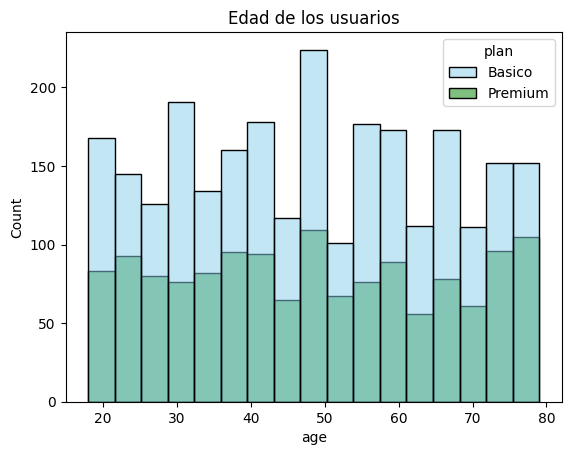

In [31]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x=user_profile['age'],hue='plan', palette=['skyblue','green'])
plt.title('Edad de los usuarios')
plt.show()


💡Insights:
- Se puede ver que la edad de los usuarios está distribuida de forma bastante uniforme entre los 18 y los 80 años, por lo que ConnectaTel tiene clientes de diferentes grupos de edad.

-También se observa que tanto el plan Básico como el Premium tienen una distribución muy parecida, es decir, no parece que la edad influya mucho en el tipo de plan que eligen los usuarios.

-Esto me hace pensar que para segmentar mejor a los clientes sería más útil analizar su comportamiento de consumo que únicamente su edad.

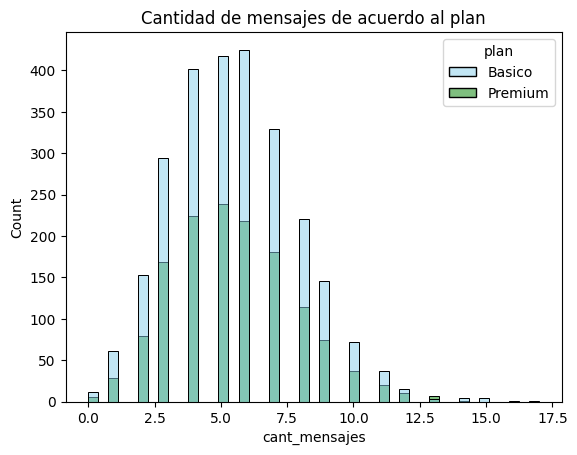

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x=user_profile['cant_mensajes'], hue='plan', palette=['skyblue','green'])
plt.title('Cantidad de mensajes de acuerdo al plan')
plt.show()

💡Insights:
- La mayoría de los usuarios envía pocos mensajes al mes, mientras que solo un grupo pequeño presenta un consumo mucho más alto.

-La distribución tiene un sesgo hacia la derecha, ya que hay pocos clientes con cantidades muy elevadas de mensajes.

-En ambos planes el comportamiento es bastante similar, por lo que el uso de mensajes no cambia demasiado dependiendo del plan contratado.

-Esto sugiere que podría ser útil ofrecer beneficios adicionales para ese pequeño grupo de usuarios que utiliza el servicio de mensajería con mayor frecuencia.


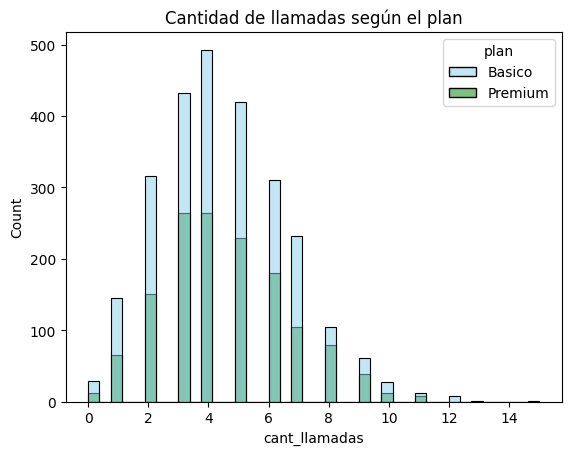

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x=user_profile['cant_llamadas'], hue='plan',palette=['skyblue','green'])
plt.title('Cantidad de llamadas según el plan')
plt.show()

💡Insights:
- La mayor parte de los clientes realiza pocas llamadas, mientras que solo algunos usuarios hacen muchas más llamadas que el promedio.

-La distribución también presenta un sesgo hacia la derecha, lo que indica que los usuarios con consumos muy altos son menos frecuentes.

-Los dos planes muestran un comportamiento parecido, aunque el plan Premium parece concentrar un poco más de usuarios con mayor cantidad de llamadas.

-Esto podría indicar que existen diferentes perfiles de clientes y que sería conveniente ofrecer planes más personalizados según el nivel de uso.


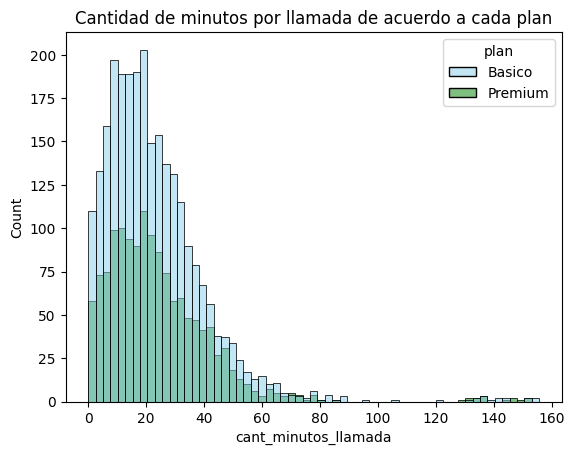

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x=user_profile['cant_minutos_llamada'], hue='plan',palette=['skyblue','green'])
plt.title('Cantidad de minutos por llamada de acuerdo a cada plan')
plt.show()

💡Insights:
- La mayoría de las llamadas tiene una duración corta o moderada, mientras que solo unas pocas superan ampliamente ese tiempo.

-Se observan algunos valores extremos, lo que significa que existen usuarios que realizan llamadas mucho más largas que el resto.

-En el plan Premium parece haber una mayor cantidad de llamadas largas, lo que podría indicar que estos clientes hacen un uso más intensivo del servicio.

-En general, estos resultados muestran que no todos los usuarios tienen las mismas necesidades, por lo que ConnectaTel podría ofrecer planes con beneficios específicos para quienes hablan durante más tiempo.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

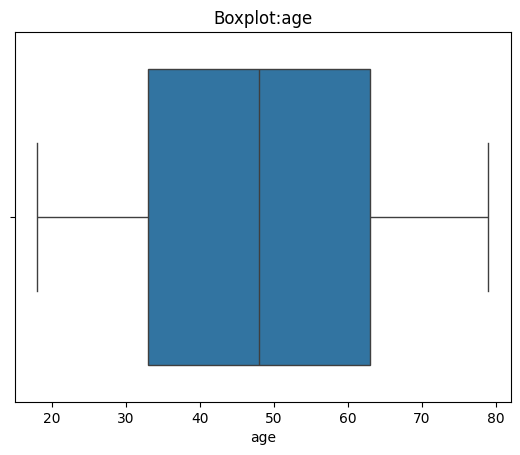

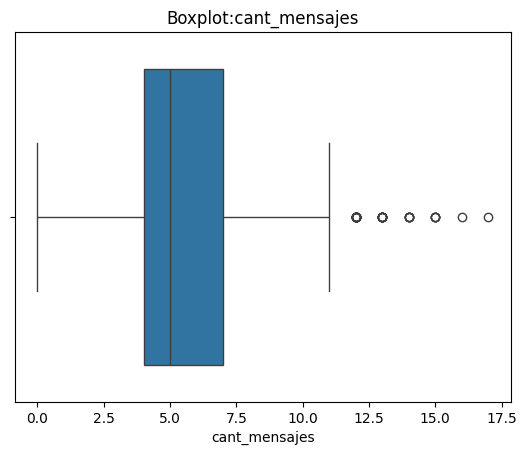

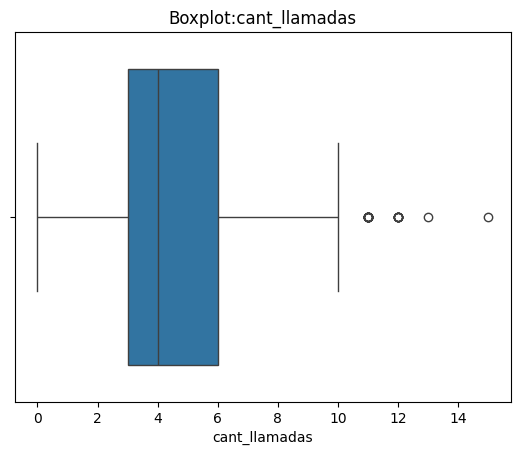

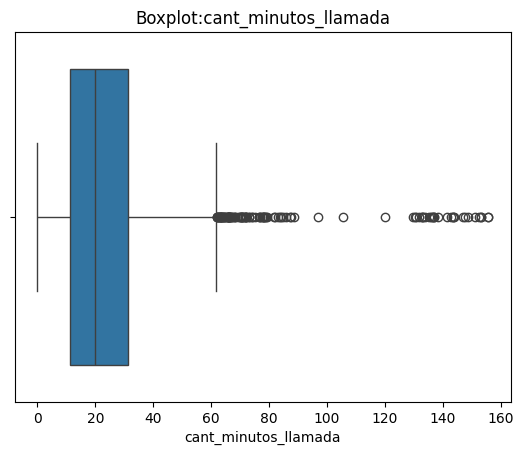

In [36]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot:{col}')
    plt.show()

💡Insights:
- Age: No presenta outliers, se ve uniformidad en el grafico,
- cant_mensajes: Si presenta outliers, se evidencia una mediana más inclinada al Q1
- cant_llamadas: Si presenta outliers, es el grafico que presenta menor cantidad de outliers, adicional se observa un rango interquantile mayor,
- cant_minutos_llamada:Si presenta gran cantidad de outliers, con sesgo a la derecha, la mediana esta un poco más equidistante entre los Q1 y Q3, el rango interquantile se observa más parejo.


In [39]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    limite_superior=Q3+1.5*IQR
    print(f'El limite de {col} es: {limite_superior}')


El limite de cant_mensajes es: 11.5
El limite de cant_llamadas es: 10.5
El limite de cant_minutos_llamada es: 61.8575


In [40]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: si mantendria esos outliers ya que son comportamientos inusuales en cantidad de mensajes pero son datos que si se pueden presentar en los clientes, ya sea por son usuarios muy activos o tuvieron alguna condicion especial.
- cant_llamadas: si mantendria esos outliers ya que son comportamientos inusuales en cantidad de llamadas pero son datos que si se pueden presentar en los clientes, ya sea por son usuarios muy activos o tuvieron alguna condicion especial.
- cant_minutos_llamada: si mantendria esos outliers ya que son comportamientos inusuales en cantidad de minutos en las llamadas pero son datos que si se pueden presentar en los clientes, ya sea por son usuarios muy activos o tuvieron alguna condicion especial.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [44]:
# Crear columna grupo_uso

condicion_bajo_uso=(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5)
condicion_uso_medio=(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
condiciones=[condicion_bajo_uso,condicion_uso_medio]
valores = ['Bajo uso', 'Uso medio']
user_profile['grupo_uso']= np.select(condiciones,valores, default='Alto uso')

In [45]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,236778,23.70,258.0,7,3,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,296458,33.18,226.0,5,10,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,111444,10.74,225.0,5,2,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,289686,8.99,530.0,11,3,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,199943,8.01,229.0,4,3,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [46]:
# Crear columna grupo_edad
condicion_joven=(user_profile['age'] < 30)
condicion_adulto=(user_profile['age'] < 60)
condiciones=[condicion_joven,condicion_adulto]
valores = ['Joven', 'Adulto']
user_profile['grupo_edad']= np.select(condiciones,valores, default='Adulto Mayor')

In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,id,cant_minutos_llamada,length,cant_mensajes,cant_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,236778,23.70,258.0,7,3,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,296458,33.18,226.0,5,10,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,111444,10.74,225.0,5,2,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,289686,8.99,530.0,11,3,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,199943,8.01,229.0,4,3,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

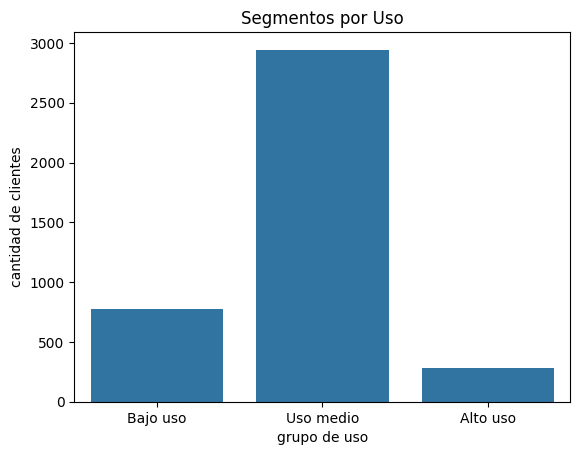

In [48]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso',
order=["Bajo uso","Uso medio","Alto uso"])
plt.title('Segmentos por Uso')
plt.xlabel('grupo de uso')
plt.ylabel('cantidad de clientes')
plt.show()

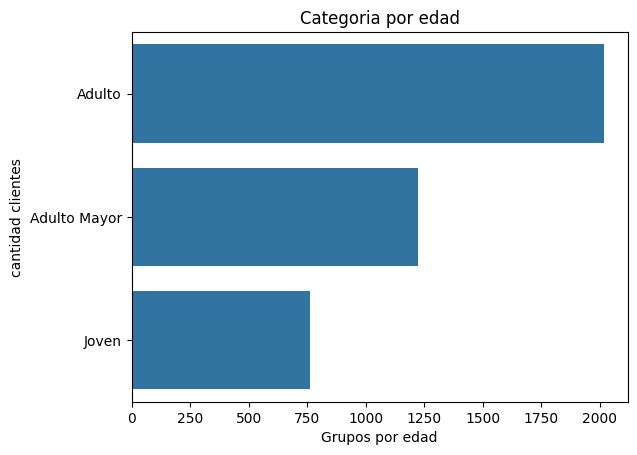

In [50]:
# Visualización de los segmentos por edad
sns.countplot(user_profile['grupo_edad'])
plt.title('Categoria por edad')
plt.xlabel('Grupos por edad')
plt.ylabel('cantidad clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En la tabla users se identificaron valores faltantes en city (469 registros, 11,7%) y en churn_date (3.534 registros, 88,35%). El alto porcentaje de valores nulos en churn_date corresponde a clientes que aún permanecen activos, por lo que no representa un error de calidad de datos.

-En la tabla usage se encontraron valores faltantes en date (50 registros, 0,13%), duration (22.076 registros, 55,19%) y length (17.896 registros, 44,74%). Estos valores faltantes se deben al tipo de interacción (por ejemplo, los mensajes no tienen duración y las llamadas no tienen longitud), por lo que corresponden a un comportamiento esperado y no a datos erróneos.

🔍 **Segmentos por Edad**
- Se clasificó a los clientes en jóvenes (<30 años), adultos (30-59 años) y adultos mayores (60 años o más) para facilitar el análisis de comportamiento.
-La mayor parte de clientes corresponde al grupo de adultos, lo que representa el segmento principal para ConnectaTel y una oportunidad para diseñar estrategias comerciales enfocadas en este perfil.


📊 **Segmentos por Nivel de Uso**
- Los usuarios fueron clasificados en bajo uso, uso medio y alto uso considerando la cantidad de llamadas y mensajes registrados.
-La mayoría de los clientes se concentra en el segmento de uso medio, mientras que existe un grupo menor de usuarios de alto uso, quienes consumen más servicios y representan clientes de mayor valor para la compañía.


Se detectaron valores atípicos en el número de llamadas, mensajes enviados y minutos consumidos. Estos registros no fueron eliminados, ya que representan comportamientos reales de algunos clientes con un consumo muy superior al promedio.

➡️ Esto sugiere que existen usuarios con necesidades de comunicación muy diferentes al resto de la población. Estos clientes pueden requerir planes especializados y, al mismo tiempo, sus patrones de consumo deben ser monitoreados para identificar oportunidades comerciales o detectar comportamientos inusuales.


💡 **Recomendaciones**
- Diseñar planes premium dirigidos a usuarios de alto consumo, incluyendo mayores cantidades de minutos y mensajes a un precio competitivo.

-Crear campañas de fidelización para los clientes de uso medio con el objetivo de incentivar su cambio hacia planes de mayor valor.

-Implementar estrategias diferenciadas por grupo de edad, ofreciendo beneficios y promociones adaptadas a las necesidades de cada segmento.

-Continuar monitoreando los usuarios con consumo extremo para identificar oportunidades comerciales, prevenir fraudes y optimizar la planificación de la capacidad de la red.